In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def view_policy(agent):
    """View the learned policy across different game states with clear color distinction"""
    player_sums = range(12, 22)  # Common player hands
    dealer_cards = range(1, 11)  # All possible dealer cards

    # Create policy table
    policy_table = np.zeros((len(player_sums), len(dealer_cards)))
    hit_probs = np.zeros((len(player_sums), len(dealer_cards)))

    # Evaluate policy for each state
    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            # Create state
            state = np.array([player_sum / 21.0, dealer_card / 10.0, 0.0])  # No usable ace

            # Get action probabilities
            with torch.no_grad():
                probs = agent.policy(torch.FloatTensor(state).unsqueeze(0))
                hit_prob = probs[0][1].item()
                hit_probs[i][j] = hit_prob
                policy_table[i][j] = 1 if hit_prob > 0.5 else 0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot deterministic policy with distinct colors
    im1 = ax1.imshow(policy_table, cmap='RdBu', vmin=0, vmax=1)
    ax1.set_title('Deterministic Policy (Red=Hit, Blue=Stand)')
    ax1.set_xlabel('Dealer Card')
    ax1.set_ylabel('Player Sum')
    ax1.set_xticks(range(len(dealer_cards)))
    ax1.set_yticks(range(len(player_sums)))
    ax1.set_xticklabels(dealer_cards)
    ax1.set_yticklabels(player_sums)

    for i in range(len(player_sums)):
        for j in range(len(dealer_cards)):
            text = "H" if policy_table[i][j] == 1 else "S"
            ax1.text(j, i, text, ha='center', va='center')

    # Plot hit probabilities
    im2 = ax2.imshow(hit_probs, cmap='RdYlBu_r')
    ax2.set_title('Hit Probabilities')
    ax2.set_xlabel('Dealer Card')
    ax2.set_ylabel('Player Sum')
    ax2.set_xticks(range(len(dealer_cards)))
    ax2.set_yticks(range(len(player_sums)))
    ax2.set_xticklabels(dealer_cards)
    ax2.set_yticklabels(player_sums)

    # Add colorbar
    plt.colorbar(im2, ax=ax2)

    plt.tight_layout()
    plt.show()

    # Print example decisions
    print("\nKey Policy Decisions:")
    print("\nPlayer Sum | Dealer Card | Hit Probability | Action")
    print("-" * 50)

    key_states = [
        (20, 10), # Strong hand vs strong dealer
        (16, 6),  # Borderline hand vs weak dealer
        (12, 2),  # Weak hand vs weak dealer
        (18, 8),  # Medium-strong hand vs medium dealer
        (14, 10), # Weak hand vs strong dealer
    ]

    for player_sum, dealer_card in key_states:
        state = np.array([player_sum / 21.0, dealer_card / 10.0, 0.0])
        with torch.no_grad():
            probs = agent.policy(torch.FloatTensor(state).unsqueeze(0))
            hit_prob = probs[0][1].item()
            action = "Hit" if hit_prob > 0.5 else "Stand"
            print(f"{player_sum:^10} | {dealer_card:^11} | {hit_prob:^14.3f} | {action:^6}")



In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random

class BlackjackEnvironment:
    def __init__(self):
        self.reset()

    def reset(self):
        self.player_sum = min(random.randint(12, 21), 21)
        self.usable_ace = random.choice([True, False])
        self.dealer_card = random.randint(1, 10)
        self.dealer_sum = self.dealer_card
        return self._get_state()

    def _get_state(self):
        return np.array([
            self.player_sum / 21.0,
            self.dealer_card / 10.0,
            float(self.usable_ace)
        ])

    def step(self, action):
        if action == 1:  # Hit
            card = min(random.randint(1, 10), 10)
            if self.usable_ace and (self.player_sum + card > 21):
                self.player_sum = self.player_sum + card - 10
                self.usable_ace = False
            else:
                self.player_sum += card

            if self.player_sum > 21:
                return self._get_state(), -1, True

            return self._get_state(), 0, False

        else:  # Stick
            while self.dealer_sum < 17:
                card = min(random.randint(1, 10), 10)
                self.dealer_sum += card

            if self.dealer_sum > 21:
                reward = 1
            elif self.dealer_sum > self.player_sum:
                reward = -1
            elif self.dealer_sum < self.player_sum:
                reward = 1
            else:
                reward = 0

            return self._get_state(), reward, True


In [5]:

class PolicyNetwork(nn.Module):
    def __init__(self, state_size=3, action_size=2):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        # Add numerical stability to prevent extreme values
        logits = self.fc2(x)
        # Clip logits to prevent numerical instability
        logits = torch.clamp(logits, -10, 10)
        return torch.softmax(logits, dim=-1)


In [7]:

class Agent:
    def __init__(self, state_size=3, action_size=2):
        self.policy = PolicyNetwork(state_size, action_size)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=0.0003)

        self.states = []
        self.actions = []
        self.rewards = []

        self.temperature = 1.0

    def get_action(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            probs = self.policy(state_tensor)
            # Ensure probs are valid probabilities
            probs = torch.clamp(probs, 1e-6, 1.0)
            probs = probs / probs.sum()
            # Apply temperature with safety checks
            if self.temperature != 1.0:
                probs = probs ** (1 / max(self.temperature, 0.1))
                probs = probs / probs.sum()
            action = torch.multinomial(probs, 1).item()
        return action

    def store_transition(self, state, action, reward):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)

    def train(self):
        if len(self.states) < 2:  # Need at least 2 samples for std calculation
            return

        states = torch.FloatTensor(self.states)
        actions = torch.LongTensor(self.actions)
        rewards = torch.FloatTensor(self.rewards)

        # Safer reward normalization
        if len(rewards) > 1:
            rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

        probs = self.policy(states)
        # Ensure probabilities are valid
        probs = torch.clamp(probs, 1e-6, 1.0)
        action_probs = probs.gather(1, actions.unsqueeze(1))

        # Safe entropy calculation
        entropy = -(probs * torch.log(probs)).sum(dim=1).mean()
        policy_loss = -(rewards * torch.log(action_probs)).mean()

        entropy_bonus = 0.01
        total_loss = policy_loss - entropy_bonus * entropy

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
        self.optimizer.step()

        self.temperature = max(0.5, self.temperature * 0.995)
        self.states = []
        self.actions = []
        self.rewards = []


In [9]:

def train_agent(env, agent, n_episodes=5000):
    rewards_history = []

    for episode in range(n_episodes):
        state = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = agent.get_action(state)
            next_state, reward, done = env.step(action)
            agent.store_transition(state, action, reward)
            agent.train()
            state = next_state
            episode_reward += reward

        rewards_history.append(episode_reward)

        if episode % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            print(f"Episode: {episode}, Average Reward: {avg_reward:.2f}")
            test_states = [
                (20, 10),  # High hand vs high card
                (16, 6),   # Medium hand vs low card
                (12, 10)   # Low hand vs high card
            ]
            print("\nCurrent policy examples:")
            for player_sum, dealer_card in test_states:
                state = np.array([player_sum/21.0, dealer_card/10.0, 0.0])
                probs = agent.policy(torch.FloatTensor(state).unsqueeze(0)).detach().numpy()[0]
                print(f"Player: {player_sum}, Dealer: {dealer_card}")
                print(f"Hit probability: {probs[1]:.3f}")

    return rewards_history


C:\Users\wayne\AppData\Local\Temp\ipykernel_17340\1025904976.py:35: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  states = torch.FloatTensor(self.states)


Episode: 0, Average Reward: -1.00

Current policy examples:
Player: 20, Dealer: 10
Hit probability: 0.560
Player: 16, Dealer: 6
Hit probability: 0.546
Player: 12, Dealer: 10
Hit probability: 0.566
Episode: 100, Average Reward: -0.26

Current policy examples:
Player: 20, Dealer: 10
Hit probability: 0.505
Player: 16, Dealer: 6
Hit probability: 0.505
Player: 12, Dealer: 10
Hit probability: 0.511
Episode: 200, Average Reward: -0.21

Current policy examples:
Player: 20, Dealer: 10
Hit probability: 0.501
Player: 16, Dealer: 6
Hit probability: 0.504
Player: 12, Dealer: 10
Hit probability: 0.502
Episode: 300, Average Reward: -0.23

Current policy examples:
Player: 20, Dealer: 10
Hit probability: 0.497
Player: 16, Dealer: 6
Hit probability: 0.503
Player: 12, Dealer: 10
Hit probability: 0.495
Episode: 400, Average Reward: -0.27

Current policy examples:
Player: 20, Dealer: 10
Hit probability: 0.498
Player: 16, Dealer: 6
Hit probability: 0.503
Player: 12, Dealer: 10
Hit probability: 0.495
Episode

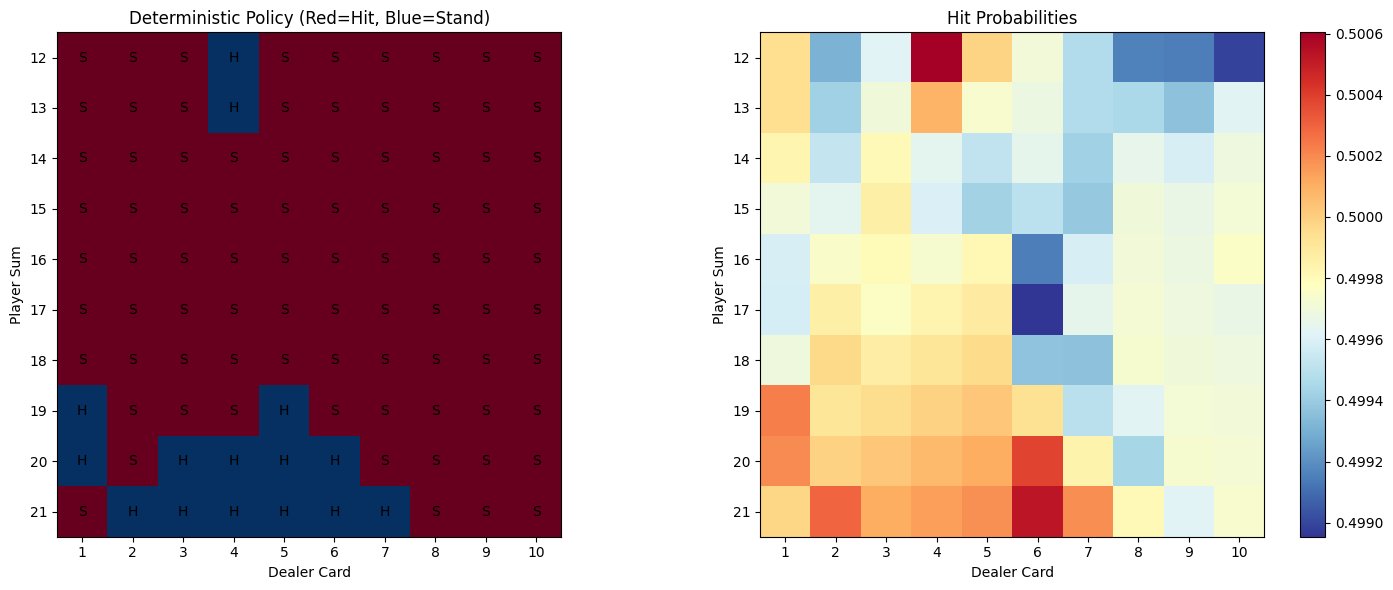


Key Policy Decisions:

Player Sum | Dealer Card | Hit Probability | Action
--------------------------------------------------
    20     |     10      |     0.500      | Stand 
    16     |      6      |     0.499      | Stand 
    12     |      2      |     0.499      | Stand 
    18     |      8      |     0.500      | Stand 
    14     |     10      |     0.500      | Stand 


In [11]:


env = BlackjackEnvironment()
agent = Agent()
train_agent(env, agent)
view_policy(agent)

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random

"""
Blackjack Reinforcement Learning Lab
----------------------------------
This lab lets you experiment with different RL approaches to playing blackjack.
Key areas to experiment with are marked with EXPERIMENT comments.

Learning Goals:
1. Understand how policy networks make decisions
2. See how different hyperparameters affect learning
3. Compare different betting strategies
4. Analyze the impact of different reward structures
"""

class BlackjackEnvironment:
    def __init__(self, initial_chips=1000, min_bet=1, max_bet_fraction=0.25, kelly_fraction=0.05):
        # EXPERIMENT: Try different starting conditions
        # - Change initial_chips for different bankroll management scenarios
        # - Adjust kelly_fraction to modify betting aggression (0.01 to 0.25)
        # - Modify max_bet_fraction to change betting limits
        self.initial_chips = initial_chips
        self.chips = initial_chips
        self.total_rebuys = 0
        self.min_bet = min_bet
        self.max_bet_fraction = max_bet_fraction
        self.kelly_fraction = kelly_fraction
        self.lifetime_profit = 0
        self.peak_bankroll = initial_chips
        self.total_hands_played = 0
        self.total_hands_won = 0

    def reset(self):
        if self.chips < self.min_bet:
            self.total_rebuys += 1
            self.chips = self.initial_chips

        # EXPERIMENT: Try different betting strategies
        # Option 1: Fixed betting
        # self.bet = self.min_bet

        # Option 2: Percentage betting
        # self.bet = max(self.min_bet, int(self.chips * 0.05))

        # Option 3: Kelly Criterion (current)
        edge = 0.51  # Estimated win probability
        kelly_bet = self.chips * (2 * edge - 1) * self.kelly_fraction
        self.bet = max(self.min_bet, min(int(kelly_bet), int(self.chips * self.max_bet_fraction)))

        # Deal initial cards
        card1, card2 = min(random.randint(1, 10), 10), min(random.randint(1, 10), 10)
        self.player_sum = card1 + card2
        self.usable_ace = (card1 == 1 or card2 == 1)
        if self.usable_ace and self.player_sum + 10 <= 21:
            self.player_sum += 10

        self.dealer_card = min(random.randint(1, 10), 10)
        self.dealer_sum = self.dealer_card

        return self._get_state()

    def _get_state(self):
        # EXPERIMENT: Try adding or removing state information
        # Example additional features you could add:
        # - Number of cards in player's hand
        # - Running count for card counting
        # - Trend of recent wins/losses
        return np.array([
            self.player_sum / 21.0,  # Normalized player sum
            self.dealer_card / 10.0,  # Normalized dealer card
            float(self.usable_ace),  # Ace information
            self.chips / self.initial_chips,  # Bankroll status
            self.bet / self.chips if self.chips > 0 else 0,  # Bet sizing
            min(self.total_rebuys, 10) / 10.0  # Rebuy history
        ])

    def step(self, action):
        """
        Execute one step of the game.

        EXPERIMENT: Try modifying the reward structure
        - Add penalties for risky play
        - Provide rewards for card counting
        - Include time-based rewards
        """
        if action == 1:  # Hit
            card = min(random.randint(1, 10), 10)
            if self.usable_ace and (self.player_sum + card > 21):
                self.player_sum = self.player_sum - 10 + card
                self.usable_ace = False
            else:
                self.player_sum += card

            if self.player_sum > 21:
                reward = -self.bet
                self.chips -= self.bet
                self.lifetime_profit -= self.bet
                self.total_hands_played += 1
                return self._get_state(), reward, True

            return self._get_state(), 0, False

        else:  # Stick
            # Dealer's turn
            while self.dealer_sum < 17:
                card = min(random.randint(1, 10), 10)
                if self.dealer_sum + card > 21:
                    self.dealer_sum = self.dealer_sum
                    break
                self.dealer_sum += card

            # Determine outcome
            if self.dealer_sum > 21 or self.dealer_sum < self.player_sum:
                reward = self.bet
                self.chips += self.bet
                self.total_hands_won += 1
                self.lifetime_profit += self.bet
            elif self.dealer_sum > self.player_sum:
                reward = -self.bet
                self.chips -= self.bet
                self.lifetime_profit -= self.bet
            else:
                reward = 0  # Push

            self.total_hands_played += 1
            self.peak_bankroll = max(self.peak_bankroll, self.chips)
            return self._get_state(), reward, True


In [15]:

# Pre-built policy networks that you can try:
class BasicPolicy(nn.Module):
    """Simple one-layer policy for learning basic strategies"""
    def __init__(self, state_size, action_size):
        super(BasicPolicy, self).__init__()
        self.fc1 = nn.Linear(state_size, action_size)

    def forward(self, x):
        return torch.softmax(self.fc1(x), dim=-1)

class ConservativePolicy(nn.Module):
    """Policy that tends toward conservative play through architecture"""
    def __init__(self, state_size, action_size):
        super(ConservativePolicy, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, action_size)
        # Higher initial bias toward standing (action 0)
        self.fc2.bias.data[0] = 1.0
        self.fc2.bias.data[1] = -1.0

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.softmax(self.fc2(x), dim=-1)

class AdvancedPolicy(nn.Module):
    """More complex policy for learning sophisticated strategies"""
    def __init__(self, state_size, action_size):
        super(AdvancedPolicy, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        return torch.softmax(self.fc3(x), dim=-1)


In [17]:

class Agent:
    def __init__(self, state_size, action_size, learning_rate=0.0003):
        # EXPERIMENT: Try different policies
        # self.policy = BasicPolicy(state_size, action_size)
        # self.policy = ConservativePolicy(state_size, action_size)
        self.policy = AdvancedPolicy(state_size, action_size)

        # EXPERIMENT: Try different optimizers
        # self.optimizer = optim.SGD(self.policy.parameters(), lr=learning_rate)
        # self.optimizer = optim.RMSprop(self.policy.parameters(), lr=learning_rate)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=learning_rate)

        # EXPERIMENT: Adjust these hyperparameters
        self.gamma = 0.99  # Discount factor (0.8 to 0.99)
        self.entropy_coef = 0.01  # Entropy coefficient (0.001 to 0.1)

    def get_action(self, state):
        """Sample action from policy."""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            probs = self.policy(state_tensor)
            action = torch.multinomial(probs, 1).item()
        return action

    def train(self, states, actions, rewards):
        """
        Train the policy using REINFORCE with baseline

        EXPERIMENT: Try modifying the training approach
        - Add a value baseline
        - Implement TD learning
        - Add experience replay
        """
        # Convert to tensors
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)

        # Calculate discounted returns
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.FloatTensor(returns)

        # Normalize returns
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Calculate policy loss with entropy bonus
        action_probs = self.policy(states)
        selected_probs = action_probs.gather(1, actions.unsqueeze(1))
        log_probs = torch.log(selected_probs)

        # EXPERIMENT: Try different loss functions
        # Basic policy gradient
        policy_loss = -(returns * log_probs).mean()

        # Add entropy bonus for exploration
        entropy = -(action_probs * torch.log(action_probs + 1e-10)).sum(dim=1).mean()
        loss = policy_loss - self.entropy_coef * entropy

        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        # EXPERIMENT: Try different gradient clipping values
        torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
        self.optimizer.step()



In [19]:

def train_agent(env, agent, n_episodes=10000):
    """
    Main training loop with performance tracking

    EXPERIMENT: Try different training approaches
    - Adjust n_episodes
    - Modify the learning rate decay
    - Change the reporting frequency
    - Add early stopping conditions
    """
    episode_rewards = []
    running_reward = 0
    best_lifetime_profit = float('-inf')
    episodes_since_profit_record = 0

    # EXPERIMENT: Add your own metrics to track
    # custom_metric = 0

    for episode in range(n_episodes):
        state = env.reset()
        done = False
        states, actions, rewards = [], [], []

        while not done:
            action = agent.get_action(state)
            next_state, reward, done = env.step(action)

            states.append(state)
            actions.append(action)
            rewards.append(reward)

            state = next_state

        # Update agent and tracking metrics
        agent.train(states, actions, rewards)
        episode_rewards.append(sum(rewards))
        running_reward = running_reward * 0.99 + sum(rewards) * 0.01

        # EXPERIMENT: Try different progress tracking approaches
        if env.lifetime_profit > best_lifetime_profit:
            best_lifetime_profit = env.lifetime_profit
            episodes_since_profit_record = 0
        else:
            episodes_since_profit_record += 1

        # Print progress
        if episode % 500 == 0:
            win_rate = (env.total_hands_won / env.total_hands_played * 100) if env.total_hands_played > 0 else 0
            print(f"\nEpisode {episode}")
            print(f"Current Bankroll: {env.chips}")
            print(f"Peak Bankroll: {env.peak_bankroll}")
            print(f"Lifetime Profit: {env.lifetime_profit}")
            print(f"Total Rebuys: {env.total_rebuys}")
            print(f"Win Rate: {win_rate:.1f}%")
            print(f"Hands Played: {env.total_hands_played}")
            print(f"Average Reward: {running_reward:.2f}")
            print("-" * 50)

"""
Main function to run the experiments

EXPERIMENT: This is where you can try different configurations
"""
# Example configurations to try:
configs = [
    {"name": "Conservative", "initial_chips": 1000, "kelly_fraction": 0.02},
    {"name": "Aggressive", "initial_chips": 1000, "kelly_fraction": 0.1},
    {"name": "High Roller", "initial_chips": 5000, "kelly_fraction": 0.05}
]

# Run baseline configuration
env = BlackjackEnvironment()
agent = Agent(state_size=6, action_size=2)
train_agent(env, agent)

# EXPERIMENT: Uncomment to try different configurations
# for config in configs:
#     print(f"\nTrying {config['name']} configuration...")
#     env = BlackjackEnvironment(
#         initial_chips=config['initial_chips'],
#         kelly_fraction=config['kelly_fraction']
#     )
#     agent = Agent(state_size=6, action_size=2)
#     train_agent(env, agent)




Episode 0
Current Bankroll: 999
Peak Bankroll: 1000
Lifetime Profit: -1
Total Rebuys: 0
Win Rate: 0.0%
Hands Played: 1
Average Reward: -0.01
--------------------------------------------------

Episode 500
Current Bankroll: 649
Peak Bankroll: 1000
Lifetime Profit: -351
Total Rebuys: 0
Win Rate: 11.8%
Hands Played: 501
Average Reward: -0.76
--------------------------------------------------

Episode 1000
Current Bankroll: 317
Peak Bankroll: 1000
Lifetime Profit: -683
Total Rebuys: 0
Win Rate: 13.2%
Hands Played: 1001
Average Reward: -0.60
--------------------------------------------------

Episode 1500
Current Bankroll: 64
Peak Bankroll: 1000
Lifetime Profit: -936
Total Rebuys: 0
Win Rate: 16.3%
Hands Played: 1501
Average Reward: -0.50
--------------------------------------------------

Episode 2000
Current Bankroll: 838
Peak Bankroll: 1000
Lifetime Profit: -1162
Total Rebuys: 1
Win Rate: 18.2%
Hands Played: 2001
Average Reward: -0.42
--------------------------------------------------



🎰 Deep Reinforcement Learning Blackjack Lab
🎰 Starting Deep RL Blackjack Training
Training for 15000 episodes...
Episode  1000: Avg Reward: -0.204, Win Rate:  34.1%, Temperature: 0.885
Episode  2000: Avg Reward: -0.063, Win Rate:  37.0%, Temperature: 0.781

POLICY ANALYSIS
Strong hand vs strong dealer
  Player: 20, Dealer: 10, Usable Ace: False
  Action probabilities: HIT 0.000, STAND 1.000
  Decision: STAND

Weak hand vs strong dealer
  Player: 16, Dealer: 10, Usable Ace: False
  Action probabilities: HIT 1.000, STAND 0.000
  Decision: HIT

Weak hand vs weak dealer
  Player: 16, Dealer: 6, Usable Ace: False
  Action probabilities: HIT 1.000, STAND 0.000
  Decision: HIT

Borderline hand vs weak dealer
  Player: 12, Dealer: 3, Usable Ace: False
  Action probabilities: HIT 1.000, STAND 0.000
  Decision: HIT

Good doubling situation
  Player: 11, Dealer: 5, Usable Ace: False
  Action probabilities: HIT 1.000, STAND 0.000
  Decision: HIT

Soft 18 vs weak dealer
  Player: 18, Dealer: 6, Usa

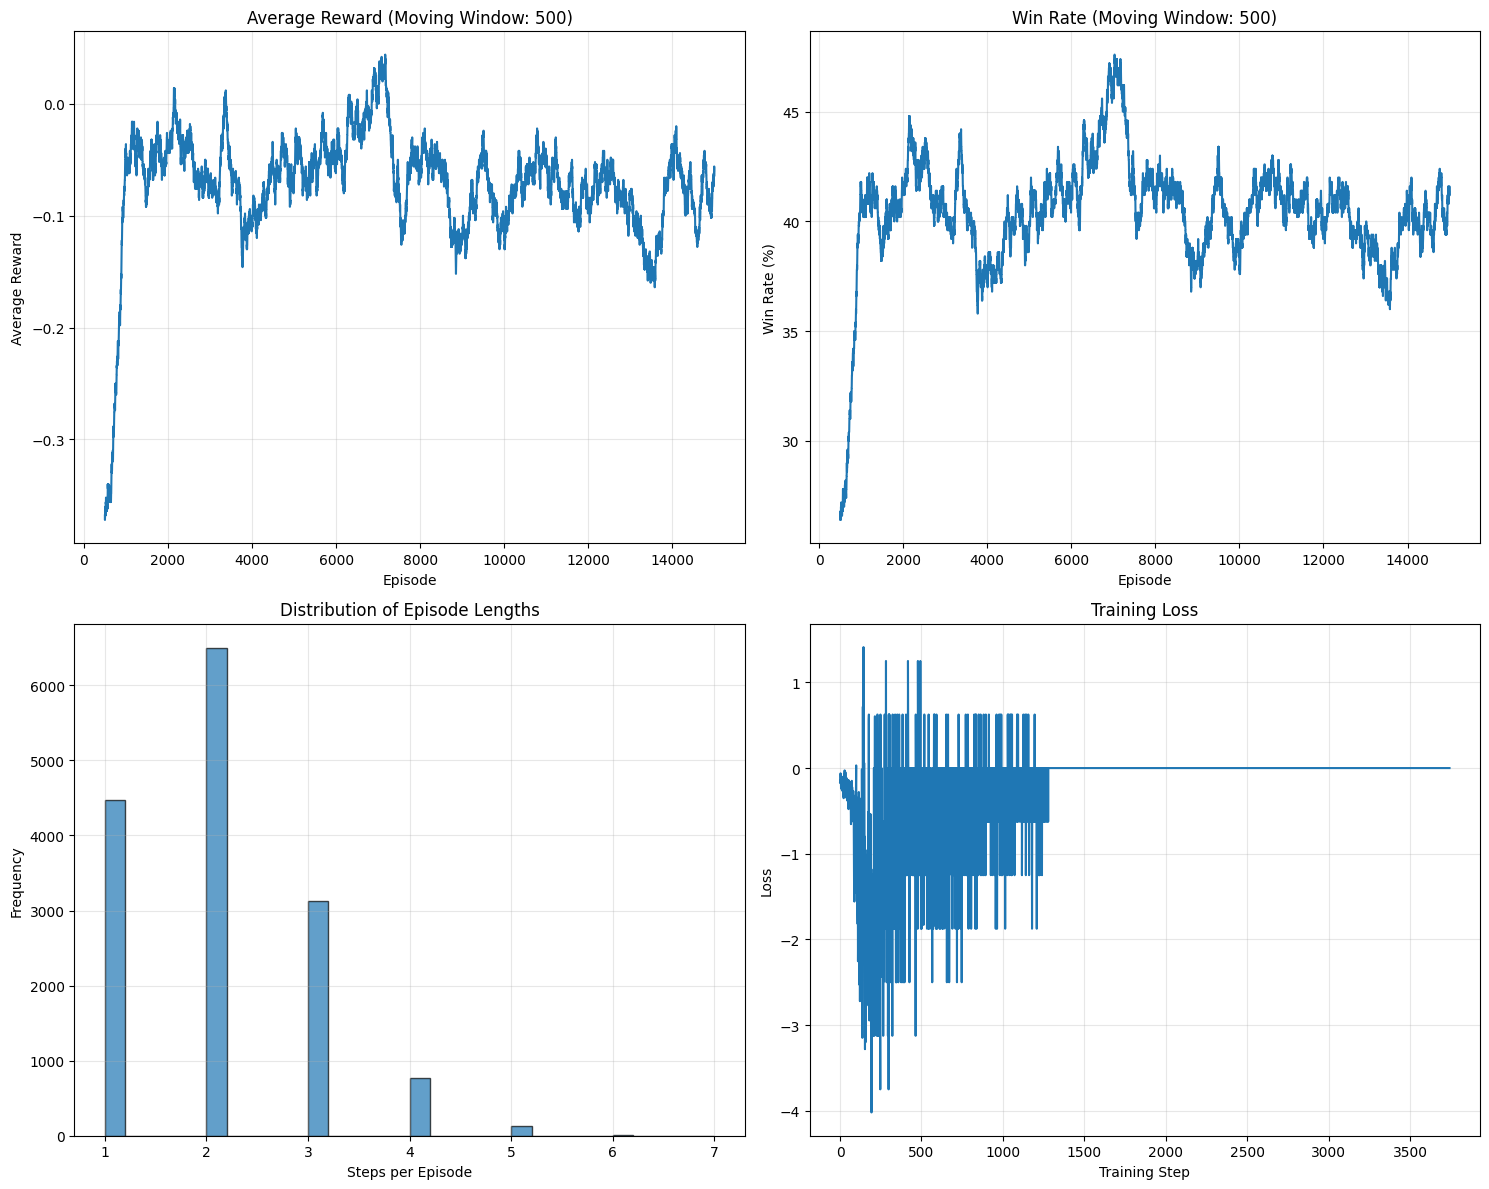


🎯 Creating strategy heatmap...


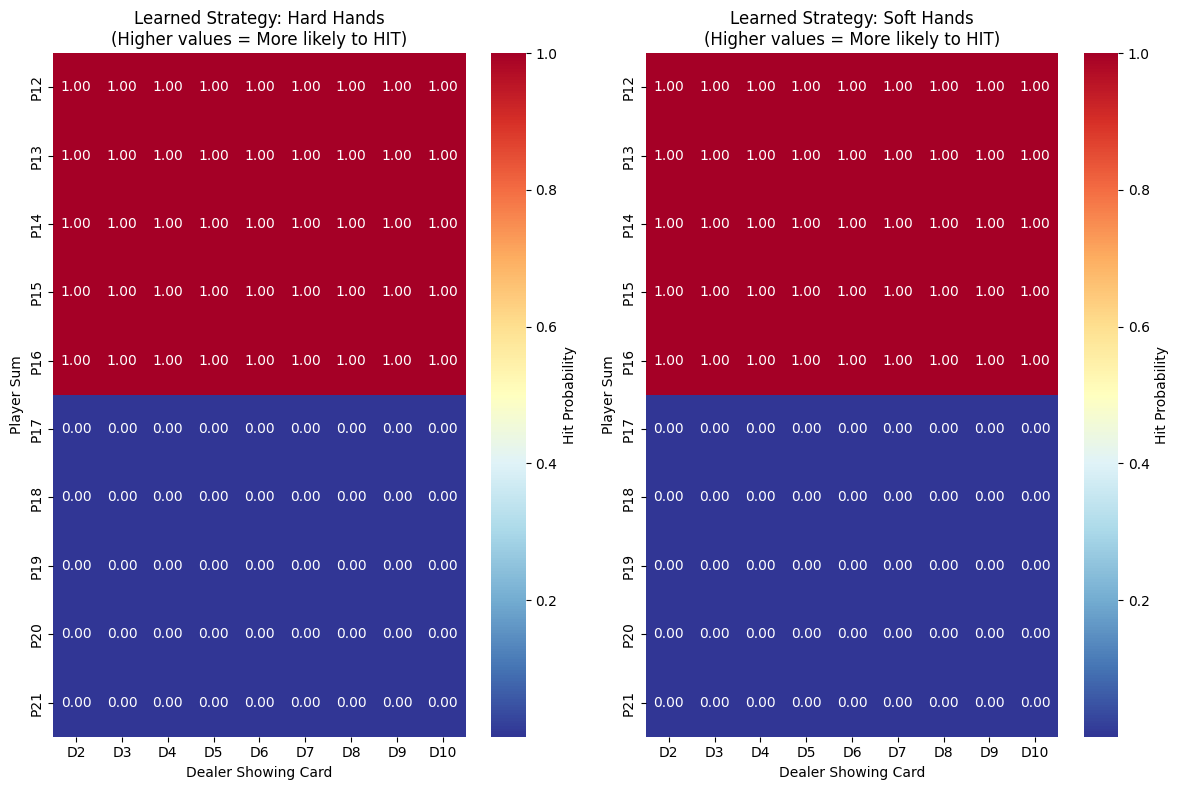


🎮 Would you like to play against the trained AI? (y/n):  y



🎮 INTERACTIVE BLACKJACK WITH TRAINED AI
You'll play alongside a trained AI agent!
Commands: 'h' = hit, 's' = stand, 'q' = quit

=== NEW HAND ===
Player: [7, 10] (Total: 17)
Dealer shows: 7

=== NEW HAND ===
Player: [4, 4] (Total: 8)
Dealer shows: 2

NEW GAME STARTED

👤 YOUR TURN:

Your hand: [4, 4] (Total: 8)
Dealer shows: 2


Hit (h) or Stand (s)?  h


Player hits: 7
Player hand: [4, 4, 7] (Total: 15)

Your hand: [4, 4, 7] (Total: 15)
Dealer shows: 2


Hit (h) or Stand (s)?  h


...

Player hits: 5
Player hand: [3, 4, 3, 4, 5] (Total: 19)

Your hand: [3, 4, 3, 4, 5] (Total: 19)
Dealer shows: 9


Hit (h) or Stand (s)?  s


Player stands
Dealer reveals: [9, 10] (Total: 19)
Dealer stands with 19
Final: Player 19 vs Dealer 19
Push (tie)!

🤖 AI'S TURN:

AI hand: [3, 5] (Total: 8)
AI decision probabilities: HIT 1.000, STAND 0.000
AI chooses to HIT

AI hand: [3, 5, 2] (Total: 10)
AI decision probabilities: HIT 1.000, STAND 0.000
AI chooses to HIT

AI hand: [3, 5, 2, 6] (Total: 16)
AI decision probabilities: HIT 1.000, STAND 0.000
AI chooses to HIT

AI hand: [3, 5, 2, 6, 3] (Total: 19)
AI decision probabilities: HIT 0.000, STAND 1.000
AI chooses to STAND



Play another hand? (y/n):  



🎓 Lab Complete! Key Takeaways:
- Deep RL can learn complex game strategies
- Policy networks map states to action probabilities
- Exploration vs exploitation is crucial for learning
- Visualization helps understand what the agent learned


In [20]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from collections import deque
import seaborn as sns

class BlackjackEnvironment:
    """
    Enhanced Blackjack environment with proper game mechanics and detailed state representation
    """
    def __init__(self, verbose=False):
        self.verbose = verbose
        self.reset()
    
    def reset(self):
        """Reset environment for new episode"""
        # Deal initial hands
        self.player_hand = [self._draw_card(), self._draw_card()]
        self.dealer_hand = [self._draw_card(), self._draw_card()]
        self.done = False
        
        if self.verbose:
            print(f"\n=== NEW HAND ===")
            print(f"Player: {self.player_hand} (Total: {self._hand_value(self.player_hand)})")
            print(f"Dealer shows: {self.dealer_hand[0]}")
        
        return self._get_state()
    
    def _draw_card(self):
        """Draw a card (1-10, where 1=Ace, 10=Face cards)"""
        return random.randint(1, 10)
    
    def _hand_value(self, hand):
        """Calculate optimal hand value handling Aces"""
        value = sum(hand)
        aces = hand.count(1)
        
        # Use Aces as 11 when beneficial
        while aces > 0 and value + 10 <= 21:
            value += 10
            aces -= 1
            
        return value
    
    def _has_usable_ace(self, hand):
        """Check if hand has an Ace counted as 11"""
        value_without_ace_bonus = sum(hand)
        value_with_ace_bonus = self._hand_value(hand)
        return value_with_ace_bonus != value_without_ace_bonus
    
    def _get_state(self):
        """Get current state representation"""
        player_sum = self._hand_value(self.player_hand)
        dealer_card = self.dealer_hand[0]
        usable_ace = self._has_usable_ace(self.player_hand)
        
        # Enhanced state representation
        state = np.array([
            player_sum / 21.0,          # Normalized player sum
            dealer_card / 10.0,         # Normalized dealer showing card
            float(usable_ace),          # Has usable ace (0 or 1)
            len(self.player_hand) / 10.0,  # Number of cards (complexity indicator)
            float(player_sum >= 17),    # Is hand "strong" (heuristic feature)
            float(dealer_card >= 7)     # Is dealer showing strong card
        ])
        
        return state
    
    def step(self, action):
        """Take action and return (state, reward, done)"""
        if self.done:
            return self._get_state(), 0, True
        
        if action == 1:  # HIT
            new_card = self._draw_card()
            self.player_hand.append(new_card)
            
            if self.verbose:
                print(f"Player hits: {new_card}")
                print(f"Player hand: {self.player_hand} (Total: {self._hand_value(self.player_hand)})")
            
            player_sum = self._hand_value(self.player_hand)
            
            if player_sum > 21:  # Player busts
                self.done = True
                if self.verbose:
                    print("Player BUSTS!")
                return self._get_state(), -1, True
            
            return self._get_state(), 0, False  # Continue playing
        
        else:  # STAND
            if self.verbose:
                print("Player stands")
            
            # Dealer plays
            dealer_sum = self._dealer_play()
            player_sum = self._hand_value(self.player_hand)
            
            # Determine winner
            reward = self._determine_winner(player_sum, dealer_sum)
            self.done = True
            
            return self._get_state(), reward, True
    
    def _dealer_play(self):
        """Dealer plays according to standard rules (hit until 17+)"""
        if self.verbose:
            print(f"Dealer reveals: {self.dealer_hand} (Total: {self._hand_value(self.dealer_hand)})")
        
        while self._hand_value(self.dealer_hand) < 17:
            new_card = self._draw_card()
            self.dealer_hand.append(new_card)
            if self.verbose:
                print(f"Dealer hits: {new_card}")
                print(f"Dealer hand: {self.dealer_hand} (Total: {self._hand_value(self.dealer_hand)})")
        
        dealer_sum = self._hand_value(self.dealer_hand)
        if self.verbose:
            if dealer_sum > 21:
                print("Dealer BUSTS!")
            else:
                print(f"Dealer stands with {dealer_sum}")
        
        return dealer_sum
    
    def _determine_winner(self, player_sum, dealer_sum):
        """Determine game outcome and return reward"""
        if dealer_sum > 21:  # Dealer busts
            reward = 1
            result = "Player wins (Dealer bust)!"
        elif player_sum > dealer_sum:
            reward = 1
            result = "Player wins!"
        elif player_sum < dealer_sum:
            reward = -1
            result = "Dealer wins!"
        else:
            reward = 0
            result = "Push (tie)!"
        
        if self.verbose:
            print(f"Final: Player {player_sum} vs Dealer {dealer_sum}")
            print(result)
        
        return reward

class EnhancedPolicyNetwork(nn.Module):
    """
    Enhanced neural network with better architecture and regularization
    """
    def __init__(self, state_size=6, action_size=2, hidden_size=128):
        super(EnhancedPolicyNetwork, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, action_size)
        )
        
        # Initialize weights
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        logits = self.network(x)
        # Numerical stability
        logits = torch.clamp(logits, -10, 10)
        return torch.softmax(logits, dim=-1)

class ImprovedAgent:
    """
    Enhanced RL agent with better training stability and analysis tools
    """
    def __init__(self, state_size=6, action_size=2, learning_rate=0.001):
        self.state_size = state_size
        self.action_size = action_size
        
        # Neural network
        self.policy = EnhancedPolicyNetwork(state_size, action_size)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=learning_rate)
        
        # Experience storage
        self.memory = deque(maxlen=10000)
        self.batch_size = 32
        
        # Training parameters
        self.gamma = 0.99  # Discount factor
        self.entropy_weight = 0.01
        self.temperature = 1.0
        self.min_temperature = 0.1
        self.temperature_decay = 0.9995
        
        # Training statistics
        self.episode_rewards = []
        self.episode_lengths = []
        self.loss_history = []
    
    def get_action(self, state, training=True):
        """Select action using current policy"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        
        with torch.no_grad():
            action_probs = self.policy(state_tensor)
            
            if training:
                # Apply temperature for exploration
                if self.temperature != 1.0:
                    action_probs = action_probs ** (1 / max(self.temperature, self.min_temperature))
                    action_probs = action_probs / action_probs.sum()
                
                # Sample action
                action = torch.multinomial(action_probs, 1).item()
            else:
                # Greedy action for testing
                action = torch.argmax(action_probs, dim=1).item()
        
        return action, action_probs.squeeze().numpy()
    
    def store_experience(self, state, action, reward, next_state, done):
        """Store experience in replay buffer"""
        self.memory.append((state, action, reward, next_state, done))
    
    def train_batch(self):
        """Train on a batch of experiences"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Sample batch
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # Convert to tensors
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        
        # Get action probabilities
        action_probs = self.policy(states)
        selected_action_probs = action_probs.gather(1, actions.unsqueeze(1))
        
        # Calculate loss
        policy_loss = -torch.log(selected_action_probs.squeeze()) * rewards
        
        # Entropy bonus for exploration
        entropy = -(action_probs * torch.log(action_probs + 1e-8)).sum(dim=1)
        
        # Total loss
        total_loss = policy_loss.mean() - self.entropy_weight * entropy.mean()
        
        # Backward pass
        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
        self.optimizer.step()
        
        # Update temperature
        self.temperature = max(self.min_temperature, self.temperature * self.temperature_decay)
        
        self.loss_history.append(total_loss.item())
        return total_loss.item()
    
    def analyze_policy(self, verbose=True):
        """Analyze the current policy on key game situations"""
        test_situations = [
            # (player_sum, dealer_card, usable_ace, description)
            (20, 10, False, "Strong hand vs strong dealer"),
            (16, 10, False, "Weak hand vs strong dealer"),
            (16, 6, False, "Weak hand vs weak dealer"),
            (12, 3, False, "Borderline hand vs weak dealer"),
            (11, 5, False, "Good doubling situation"),
            (18, 6, True, "Soft 18 vs weak dealer"),
            (13, 10, True, "Soft 13 vs strong dealer"),
        ]
        
        policy_analysis = []
        
        if verbose:
            print("\n" + "="*60)
            print("POLICY ANALYSIS")
            print("="*60)
        
        for player_sum, dealer_card, usable_ace, description in test_situations:
            # Create state
            state = np.array([
                player_sum / 21.0,
                dealer_card / 10.0,
                float(usable_ace),
                2 / 10.0,  # Assume 2 cards initially
                float(player_sum >= 17),
                float(dealer_card >= 7)
            ])
            
            _, probs = self.get_action(state, training=False)
            hit_prob = probs[1]
            stand_prob = probs[0]
            
            policy_analysis.append({
                'situation': description,
                'player_sum': player_sum,
                'dealer_card': dealer_card,
                'usable_ace': usable_ace,
                'hit_prob': hit_prob,
                'stand_prob': stand_prob,
                'decision': 'HIT' if hit_prob > stand_prob else 'STAND'
            })
            
            if verbose:
                print(f"{description}")
                print(f"  Player: {player_sum}, Dealer: {dealer_card}, Usable Ace: {usable_ace}")
                print(f"  Action probabilities: HIT {hit_prob:.3f}, STAND {stand_prob:.3f}")
                print(f"  Decision: {'HIT' if hit_prob > stand_prob else 'STAND'}")
                print()
        
        return policy_analysis

def train_agent_with_analysis(episodes=10000, verbose_training=False):
    """
    Comprehensive training with detailed analysis and visualization
    """
    env = BlackjackEnvironment(verbose=False)
    agent = ImprovedAgent()
    
    print("🎰 Starting Deep RL Blackjack Training")
    print(f"Training for {episodes} episodes...")
    
    # Training metrics
    wins = 0
    losses = 0
    draws = 0
    
    for episode in range(episodes):
        state = env.reset()
        episode_reward = 0
        episode_length = 0
        
        while True:
            action, _ = agent.get_action(state, training=True)
            next_state, reward, done = env.step(action)
            
            # Store experience
            agent.store_experience(state, action, reward, next_state, done)
            
            episode_reward += reward
            episode_length += 1
            state = next_state
            
            if done:
                # Track outcomes
                if reward > 0:
                    wins += 1
                elif reward < 0:
                    losses += 1
                else:
                    draws += 1
                break
        
        # Train on batch
        if episode % 4 == 0:  # Train every 4 episodes
            agent.train_batch()
        
        # Store episode statistics
        agent.episode_rewards.append(episode_reward)
        agent.episode_lengths.append(episode_length)
        
        # Progress reporting
        if (episode + 1) % 1000 == 0:
            recent_rewards = agent.episode_rewards[-1000:]
            avg_reward = np.mean(recent_rewards)
            win_rate = wins / (episode + 1) * 100
            
            print(f"Episode {episode + 1:5d}: "
                  f"Avg Reward: {avg_reward:6.3f}, "
                  f"Win Rate: {win_rate:5.1f}%, "
                  f"Temperature: {agent.temperature:.3f}")
            
            if verbose_training and (episode + 1) % 2000 == 0:
                agent.analyze_policy(verbose=True)
    
    print(f"\n🏁 Training Complete!")
    print(f"Final Results: {wins} wins, {losses} losses, {draws} draws")
    print(f"Final Win Rate: {wins/(wins+losses+draws)*100:.1f}%")
    
    return agent, env

def visualize_training_results(agent):
    """Create comprehensive visualizations of training results"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Reward progression
    window_size = 500
    if len(agent.episode_rewards) >= window_size:
        smoothed_rewards = []
        for i in range(window_size-1, len(agent.episode_rewards)):
            smoothed_rewards.append(np.mean(agent.episode_rewards[i-window_size+1:i+1]))
        
        ax1.plot(range(window_size-1, len(agent.episode_rewards)), smoothed_rewards)
        ax1.set_title(f'Average Reward (Moving Window: {window_size})')
        ax1.set_xlabel('Episode')
        ax1.set_ylabel('Average Reward')
        ax1.grid(True, alpha=0.3)
    
    # 2. Win rate progression
    wins = np.array(agent.episode_rewards) > 0
    if len(wins) >= window_size:
        win_rates = []
        for i in range(window_size-1, len(wins)):
            win_rates.append(np.mean(wins[i-window_size+1:i+1]) * 100)
        
        ax2.plot(range(window_size-1, len(wins)), win_rates)
        ax2.set_title(f'Win Rate (Moving Window: {window_size})')
        ax2.set_xlabel('Episode')
        ax2.set_ylabel('Win Rate (%)')
        ax2.grid(True, alpha=0.3)
    
    # 3. Episode length distribution
    ax3.hist(agent.episode_lengths, bins=30, alpha=0.7, edgecolor='black')
    ax3.set_title('Distribution of Episode Lengths')
    ax3.set_xlabel('Steps per Episode')
    ax3.set_ylabel('Frequency')
    ax3.grid(True, alpha=0.3)
    
    # 4. Loss progression
    if agent.loss_history:
        ax4.plot(agent.loss_history)
        ax4.set_title('Training Loss')
        ax4.set_xlabel('Training Step')
        ax4.set_ylabel('Loss')
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def create_strategy_heatmap(agent):
    """Create a heatmap showing the learned strategy"""
    
    # Create grid of situations
    player_sums = range(12, 22)  # 12-21
    dealer_cards = range(2, 11)  # 2-10, A
    
    # For hard hands (no usable ace)
    hard_strategy = np.zeros((len(player_sums), len(dealer_cards)))
    
    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = np.array([
                player_sum / 21.0,
                dealer_card / 10.0,
                0.0,  # No usable ace
                2 / 10.0,  # 2 cards
                float(player_sum >= 17),
                float(dealer_card >= 7)
            ])
            
            _, probs = agent.get_action(state, training=False)
            hard_strategy[i, j] = probs[1]  # Probability of hitting
    
    # Create heatmap
    plt.figure(figsize=(12, 8))
    
    # Hard hands heatmap
    plt.subplot(1, 2, 1)
    sns.heatmap(hard_strategy, 
                xticklabels=[f'D{card}' for card in dealer_cards],
                yticklabels=[f'P{sum}' for sum in player_sums],
                annot=True, fmt='.2f', cmap='RdYlBu_r',
                cbar_kws={'label': 'Hit Probability'})
    plt.title('Learned Strategy: Hard Hands\n(Higher values = More likely to HIT)')
    plt.xlabel('Dealer Showing Card')
    plt.ylabel('Player Sum')
    
    # For soft hands (usable ace)
    soft_strategy = np.zeros((len(player_sums), len(dealer_cards)))
    
    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = np.array([
                player_sum / 21.0,
                dealer_card / 10.0,
                1.0,  # Usable ace
                2 / 10.0,  # 2 cards
                float(player_sum >= 17),
                float(dealer_card >= 7)
            ])
            
            _, probs = agent.get_action(state, training=False)
            soft_strategy[i, j] = probs[1]  # Probability of hitting
    
    plt.subplot(1, 2, 2)
    sns.heatmap(soft_strategy, 
                xticklabels=[f'D{card}' for card in dealer_cards],
                yticklabels=[f'P{sum}' for sum in player_sums],
                annot=True, fmt='.2f', cmap='RdYlBu_r',
                cbar_kws={'label': 'Hit Probability'})
    plt.title('Learned Strategy: Soft Hands\n(Higher values = More likely to HIT)')
    plt.xlabel('Dealer Showing Card')
    plt.ylabel('Player Sum')
    
    plt.tight_layout()
    plt.show()

def interactive_game_with_ai(agent, env):
    """
    Interactive game where human plays against the trained AI
    """
    print("\n" + "="*60)
    print("🎮 INTERACTIVE BLACKJACK WITH TRAINED AI")
    print("="*60)
    print("You'll play alongside a trained AI agent!")
    print("Commands: 'h' = hit, 's' = stand, 'q' = quit")
    
    while True:
        # Reset for new game
        env_human = BlackjackEnvironment(verbose=True)
        env_ai = BlackjackEnvironment(verbose=False)
        
        # Start new hands
        human_state = env_human.reset()
        ai_state = env_ai.reset()
        
        print(f"\n{'='*60}")
        print("NEW GAME STARTED")
        print(f"{'='*60}")
        
        # Human turn
        print("\n👤 YOUR TURN:")
        human_done = False
        while not human_done:
            print(f"\nYour hand: {env_human.player_hand} (Total: {env_human._hand_value(env_human.player_hand)})")
            print(f"Dealer shows: {env_human.dealer_hand[0]}")
            
            action = input("Hit (h) or Stand (s)? ").strip().lower()
            
            if action == 'q':
                return
            elif action == 'h':
                human_state, reward, human_done = env_human.step(1)
            elif action == 's':
                human_state, reward, human_done = env_human.step(0)
            else:
                print("Invalid input! Use 'h', 's', or 'q'")
                continue
        
        # AI turn
        print("\n🤖 AI'S TURN:")
        ai_done = False
        while not ai_done:
            action, probs = agent.get_action(ai_state, training=False)
            print(f"\nAI hand: {env_ai.player_hand} (Total: {env_ai._hand_value(env_ai.player_hand)})")
            print(f"AI decision probabilities: HIT {probs[1]:.3f}, STAND {probs[0]:.3f}")
            
            if action == 1:
                print("AI chooses to HIT")
            else:
                print("AI chooses to STAND")
            
            ai_state, ai_reward, ai_done = env_ai.step(action)
        
        # Play again?
        play_again = input("\nPlay another hand? (y/n): ").strip().lower()
        if play_again != 'y':
            break

# Main execution function
def main():
    """
    Main function to run the complete deep RL blackjack demonstration
    """
    print("🎰 Deep Reinforcement Learning Blackjack Lab")
    print("=" * 50)
    
    # Train the agent
    agent, env = train_agent_with_analysis(episodes=15000, verbose_training=True)
    
    # Analyze the final policy
    print("\n" + "="*60)
    print("FINAL POLICY ANALYSIS")
    print("="*60)
    policy_analysis = agent.analyze_policy(verbose=True)
    
    # Create visualizations
    print("\n📊 Creating training visualizations...")
    visualize_training_results(agent)
    
    print("\n🎯 Creating strategy heatmap...")
    create_strategy_heatmap(agent)
    
    # Interactive game option
    play_interactive = input("\n🎮 Would you like to play against the trained AI? (y/n): ").strip().lower()
    if play_interactive == 'y':
        interactive_game_with_ai(agent, env)
    
    print("\n🎓 Lab Complete! Key Takeaways:")
    print("- Deep RL can learn complex game strategies")
    print("- Policy networks map states to action probabilities")
    print("- Exploration vs exploitation is crucial for learning")
    print("- Visualization helps understand what the agent learned")
    
    return agent, env

if __name__ == "__main__":
    # Run the complete demo
    trained_agent, environment = main()

In [25]:
#game = BlackjackGame(agent)
#game.play_game()
